# Generator 参数化演示

对应 01_generator.ipynb 的表单工作流, 这里直接用后端: 解析现成
INPUT 卡 -> 修改 Nemit_x -> 重写 -> 运行 Generator -> 对比束团。

发射度单位 pi mm mrad (数值 = mm.mrad, 与 ASTRA 打印一致)。

In [1]:
%run ../notebooks/_bootstrap.py

astra-notebook 后端已加载 (v0.1.0)
项目根目录: /Users/yuxinwu/my_projects/astra_notebook
模拟工作目录: /Users/yuxinwu/my_projects/astra_notebook/data/workspace
ASTRA    : /Users/yuxinwu/programs/ASTRA/astra
Generator: /Users/yuxinwu/programs/ASTRA/generator


In [2]:
from astra_tools.namelist.parse import parse_namelists
from astra_tools.namelist.write import write_input_deck
from astra_tools.deck.metadata import param_info
from astra_tools.run import run_program, check_executable
from astra_tools.io import read_distribution

nl, p = param_info("Nemit_x")
print("Nemit_x 元数据:", nl, "| 单位:", p["unit"])
print("描述:", p["desc"][:100], "...")
print()

seed = parse_namelists(PROJECT_ROOT / "examples/Plasma_Example_1/phsp.in")
print("INPUT 卡参数数:", len(seed["INPUT"]))

Nemit_x 元数据: INPUT | 单位: π mrad mm
描述: normalized transverse emittance in the horizontal direction. Can be specified instead of a transvers ...

INPUT 卡参数数: 28


In [3]:
# 两个发射度各生成一个束团
work = SIM_DIR / "generator_demo"
work.mkdir(parents=True, exist_ok=True)
gen = check_executable("generator")
results = {}
for nemit in (0.1, 1.0):
    seed["INPUT"]["Nemit_x"] = nemit
    seed["INPUT"]["Nemit_y"] = nemit
    deck = work / ("phsp_%g.in" % nemit)
    write_input_deck(seed, deck, header="generator demo Nemit=%g" % nemit)
    run_program(gen, work, input_file=deck.name)
    results[nemit] = read_distribution(work / "phsp.ini")
print("生成完成")

 --------------------------------------------------------------------------

                              generator              
               Version 1.0 - macOS 64bit - Apple Silicon
                        DESY,  Hamburg 2002          
                        Tue Aug 18 03:30:04 

     Working File is:    phsp_0.1.in                                       
     Initializing       1000      electrons
     including 6 probe particles at standard positions
     Particles are quasi randomly distributed

     Final check:
     Particles taken into account      N =       1000
     total charge                      Q =    -1.0000E-04 nC
     horizontal beam position          x =     1.7439E-07 mm
     vertical beam position            y =     1.5831E-08 mm
     longitudinal beam position        z =     3.0448E-11 m
     horizontal beam size          sig x =     1.5786E-03 mm
     vertical beam size            sig y =     1.5796E-03 mm
     longitudinal beam size        sig z =     9.8772

Nemit = 0.1 -> eps_nx = 0.096 pi mm mrad (应回到输入值)


Nemit = 1 -> eps_nx = 0.962 pi mm mrad (应回到输入值)


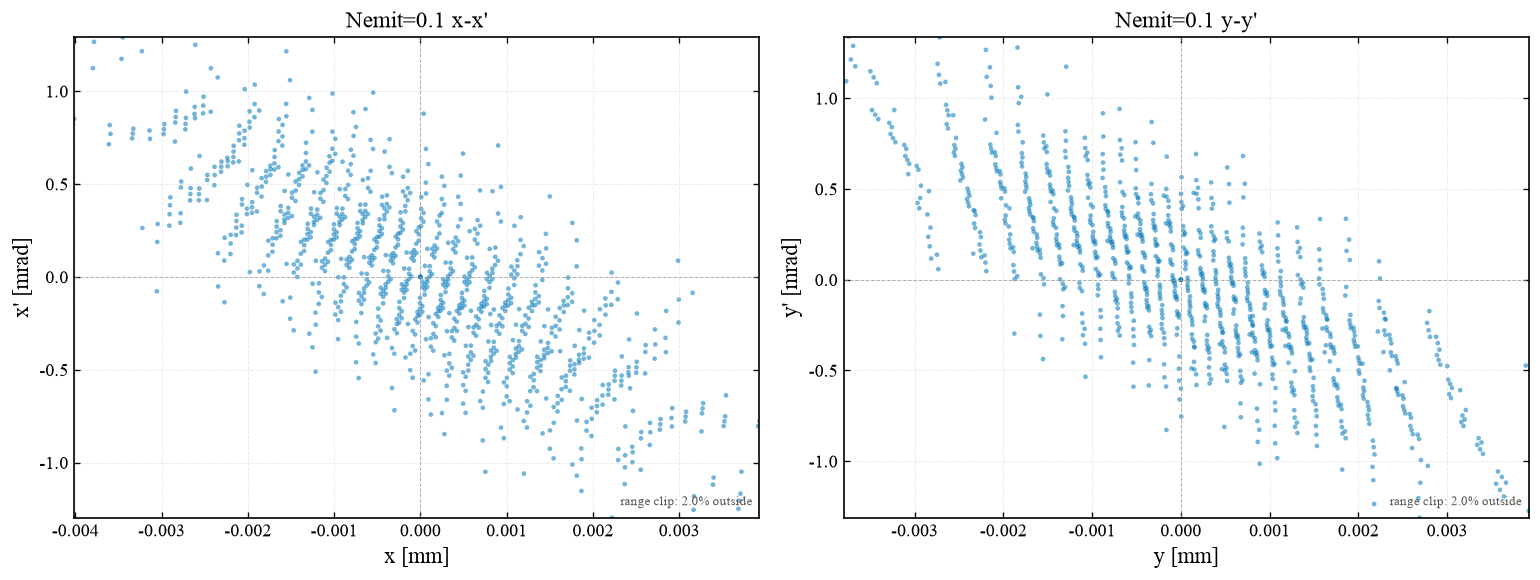

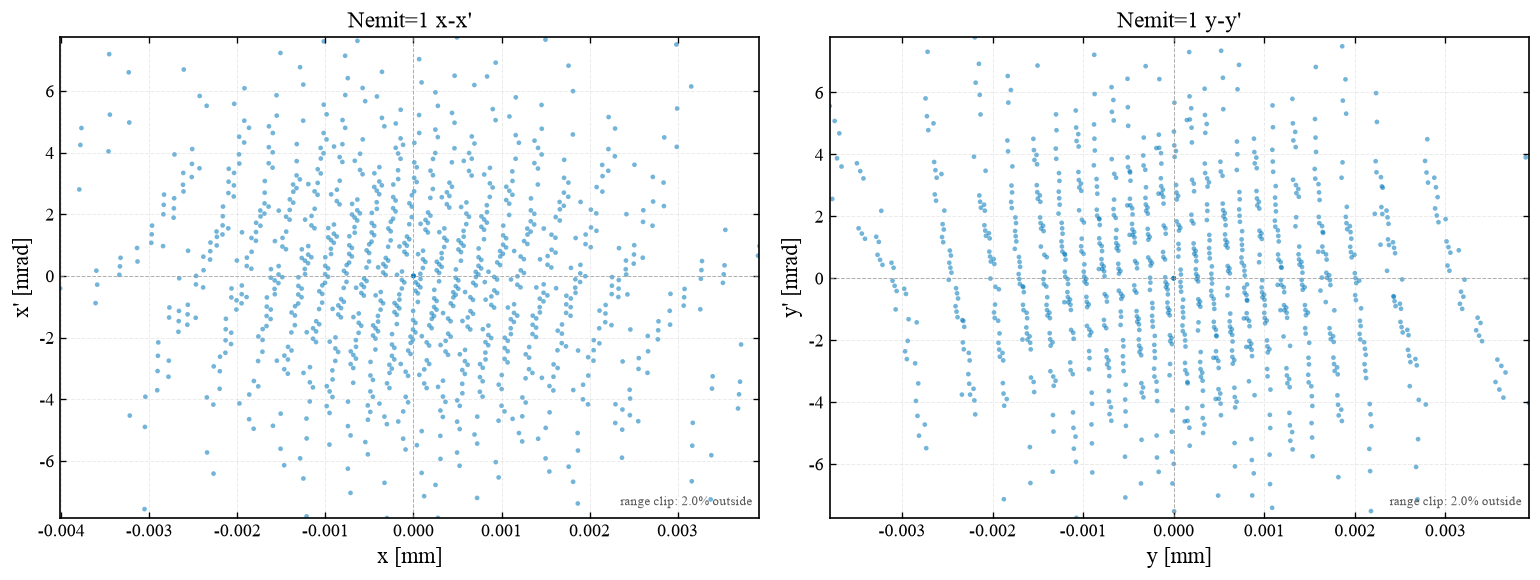

In [4]:
from astra_tools.analysis.statistics import compute_statistics
from astra_tools.widgets.panels import stats_table_html
from astra_tools.plot.phase_space import plot_transverse_phase_space

for nemit, d in results.items():
    s = compute_statistics(d)
    print("Nemit = %g -> eps_nx = %.3f pi mm mrad (应回到输入值)" % (
        nemit, s.emit_x_norm * 1e6))
    stats_table_html(s)
    plot_transverse_phase_space(d, title_prefix="Nemit=%g" % nemit)

说明: Nemit 是初始束团归一化发射度, 生成后统计应还原该值 —
这是 Generator 输入/输出一致性的直接演示 (交叉验证层的另一形式)。